<div style="background-color: #d9ffd4; padding: 20px; border-radius: 10px;">
    <h1 style="color: #2F4F4F; font-family: Calibri, sans-serif; text-align: center;">Clase 16</h1>
    <p style="color: #2F4F4F; font-family: Calibri, Courier, monospace; text-align: center; font-size: 24px;">
        Ecuaciones Diferenciales: Método de Runge-Kutta de orden 2 y aplicación en física
    </p>
</div>

<div style="background-color: #d4eeff; color: black; padding: 10px; border-radius: 5px;">

### **Método de Runge-Kutta de orden 2**

Considere una ecuación diferencial ordinaria de primer orden en su forma estándar:

$$ \frac{dy}{dt} = f(t, y) $$

El método RK2 estima $y_{n+1}$ a partir de $y_n$ y $t_n$, con un paso $h$, utilizando una pendiente mejorada. El procedimiento consta de los siguientes pasos:

1. Calcular una pendiente inicial (como en el método de Euler):

$$ k_1 = h \cdot  f(t_n, y_n) $$

2. Usar esta pendiente $k_1$ para estimar un valor intermedio:

$$ y_\text{mid} = y_n + \frac{k_1}{2} ~~,~~ t_\text{mid} = t_n + \frac{h}{2} $$

3. Calcular la pendiente en el punto medio:

$$ k_2 = h \cdot f(t_\text{mid}, y_\text{mid}) $$

4. Calcular el valor siguiente de $y$:

$$ \boxed{ y_{n+1} = y_n + k_2  } $$

5. Avanzar en el tiempo:

$$ \boxed{ t_{n+1} = t_n + h } $$

**Nota:** Este método usa la pendiente en el punto medio para mejorar la estimación del incremento de $y$, y suele dar mejores resultados que el método de Euler simple, especialmente cuando $f(t,y)$ varía rápidamente.

</div>

#### **Interpretación Gráfica**

La gráfica siguiente muestra cómo el método RK2 mejora la estimación de $y_1$ al usar no solo la pendiente inicial ($k_1$, en rojo), sino también una pendiente corregida en un punto medio ($k_2$, en azul). Esta pendiente intermedia se alinea mejor con la pendiente real de la solución (línea punteada verde), lo que da como resultado una aproximación más precisa al valor de la solución exacta (línea negra).

<p align="center">
  <img src="comparison_v2.png" style="max-width: 60%; height: auto;">
</p>

<div style="background-color: #FFF9AD; color: black; padding: 10px; border-radius: 5px;">

**Ejercicio:** Defina una función en Python para implementar el método de RK2, use como ejemplo el código siguiente donde se define Euler:

</div>

In [12]:
import numpy as np

def euler_method(f, t0, y0, h, tf):
    """Euler method to solve first-order ordinary differential equations (ODEs)"""

    # Discrete values of the independent variable
    t = np.arange(start=t0, stop=tf + h, step=h)

    # Array to store values of the dependent variable
    y = np.zeros_like(t)

    # Initial condition
    y[0] = y0

    # Iterative Euler update
    for n in range(len(t) - 1):
        y[n + 1] = y[n] + h * f(t[n], y[n])

    return t, y

def rk2_method(f, t0, y0, h, tf):
    """Runge-Kutta method of order 2 to solve first-order ordinary differential equations (ODEs)"""

    # Discrete values of the independent variable
    t = np.arange(start=t0, stop=tf + h, step=h)

    # Array to store values of the dependent variable
    y = np.zeros_like(t)

    # Initial condition
    y[0] = y0

    # Iterative RK2 update
    for n in range(len(t) - 1):
        k1 = h * f(t[n], y[n])

        t_mid = t[n] + h/2
        y_mid = y[n] + k1/2

        k2 = h * f(t_mid, y_mid)

        y[n+1] = y[n] + k2

    return t, y

<div style="background-color: #FFF9AD; color: black; padding: 10px; border-radius: 5px;">

### **Temperatura de una habitación**

Considere una habitación con una fuente de calor interna (como un calefactor, una estufa o un aire acondicionado) cuya temperatura $T_\text{fuente} (t)$ varía en el tiempo. La temperatura de la habitación, $T(t)$, puede modelarse mediante la siguiente ecuación diferencial:

$$
\frac{dT}{dt} = \frac{ T_{\text{fuente}}(t) - T(t)}{\tau}
$$

$ \tau $ es una constante que indica qué tan rápido la temperatura de la habitación se ajusta a la temperatura de la fuente.

Resuelva esta ecuación diferencial aplicando el método de Runge-Kutta de segundo orden (RK2) y el método de Euler.
Considere que la función $ T_{\text{fuente}}(t) $ está definida por tramos, de la siguiente manera:

$$
T_{\text{fuente}}(t) =
\begin{cases}
T_{\text{baja}}, & 0 \text{ s} \leq t < 30 \text{ s} \\[6pt]
T_{\text{alta}}, & 30 \text{ s} \leq t < 80 \text{ s} \\[6pt]
T_{\text{baja}}, & 80 \text{ s} \leq t < 120 \text{ s}\\[6pt]
T_\text{alta} - 0.1 \cdot (t - 80) + 2 \cdot \text{fluctuaciones aleatorias}, & 120 \text{ s} \leq t \leq 200 \text{ s}
\end{cases}
$$

Use los siguientes valores para los parámetros y constantes: $ \tau = 16 $ s, $ T_{\text{alta}} = 26 $ °C, $ T_{\text{baja}} = 15 $ °C, $h=0.9$ s.

Considere que inicialmente la temperatura de la habitación está a $15$ °C.

Grafique la evolución de $ T(t) $ para visualizar cómo cambia la temperatura de la habitación a lo largo del tiempo.

</div>


In [13]:
np.random.random()

0.13889162371953057

La función de temperatura de la fuente $T_\text{fuente}(t)$ debería verse de la siguiente forma:

<p align="center">
  <img src="grafico_fuente.png" style="max-width: 80%; height: auto;">
</p>

Implemente su solución:

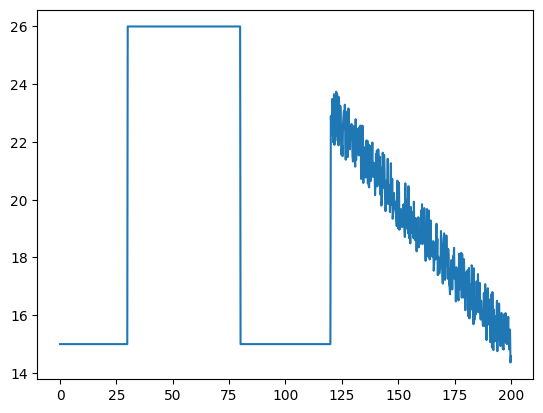

In [14]:
# código acá
def T_fuente(t_in):

    T_baja = 15 #°C
    T_alta = 26 #°C

    T = []

    for t in t_in:

        if 0 <= t <= 30:
            T.append(T_baja)
        
        elif 30 < t <= 80:
            T.append(T_alta)
        
        elif 80 < t <= 120:
            T.append(T_baja)

        else: # 120 o más
            Temp = T_alta - 0.1 * (t - 80) + 2*np.random.random()
            T.append(Temp)

    return np.array(T)


t = np.linspace(start=0, stop=200, num=1000)
#tiempo = np.linspace(0, 200, 1000)

T_f = T_fuente(t)

import matplotlib.pyplot as plt

plt.plot(t, T_f)

In [15]:
# código acá
def T_fuente(t):

    T_baja = 15 #°C
    T_alta = 26 #°C

    if 0 <= t <= 30:
        return T_baja
    
    elif 30 < t <= 80:
        return T_alta
    
    elif 80 < t <= 120:
        return T_baja

    else: # 120 o más
        Temp = T_alta - 0.1 * (t - 80) + 2*np.random.random()
        return Temp


In [16]:
def f(t, T):
    tau = 16
    return (T_fuente(t) - T)/tau

In [17]:
t, T_rk2 = rk2_method(f=f, t0=0, y0=15, h=0.9, tf=200)



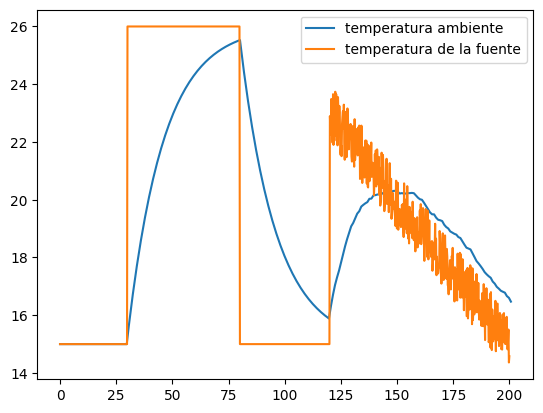

In [18]:
plt.plot(t, T_rk2, label="temperatura ambiente")

t = np.linspace(start=0, stop=200, num=1000)
plt.plot(t, T_f, label="temperatura de la fuente")

plt.legend()

<div style="background-color: #d9ffd4; color: black; padding: 10px; border-radius: 5px;">

**Conclusión: ¿Qué aprendimos?**

- Comprendimos el funcionamiento del método de Runge-Kutta de segundo orden (RK2) para aproximar soluciones de ecuaciones diferenciales de primer orden.
- Aplicamos este método para modelar la evolución de la temperatura en una habitación con una fuente de calor que varía en el tiempo.

<br>

**Próxima clase:** Ecuaciones diferenciales: Método de Runge-Kutta de cuarto orden (RK4)

</div>

<div style="padding: 15px; border-top: 2px solid #2F4F4F; margin-top: 30px; background-color: var(--custom-bg-color); color: var(--custom-text-color);">
    <p style="font-family: Calibri, sans-serif; text-align: left; font-size: 16px;">
        Omar Fernández <br>
        Profesor de Física Computacional III para Astrofísica <br>
        Ingeniero Físico <br>
        <a href="mailto:omar.fernandez.o@usach.cl" class="email-link">omar.fernandez.o@usach.cl</a> <br>
    </p>
</div>

<style>
:root {
    --custom-bg-color: #F8F8F8;
    --custom-text-color: #2F4F4F;
    --custom-link-color: blue;
}

@media (prefers-color-scheme: dark) {
    :root {
        --custom-bg-color: #444444;
        --custom-text-color: #F8F8F8;
        --custom-link-color: magenta;
    }
}

.email-link {
    color: var(--custom-link-color);
}
</style>